## Down Syndrome Feature Selection

This project seeks to determine what factors most correlate with Down Sydrome, and to create prediction models from that data.

### Common Imports

In [8]:
import pyarrow.parquet as pq
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

In [9]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### Read in Data

In [10]:
chunks = pq.ParquetFile(
    "../../../data/2021/processed/natality_2021_cleaned.parquet"
).iter_batches(batch_size=50000)
chunks = [chunk.to_pandas() for chunk in chunks]

### Feature Exclusion

Because Down syndrome is a genetic disorder, we will be primarily focused on features of pregnancy that are related to the mother and father's demographics and pre-pregnancy vital statistics, and not on features related to prenatal care or delivery.

In [11]:
unrelated_features = [
    "marital_status",
    "cigarette_recode",
    "final_route_and_method_of_delivery",
    "five_minute_apgar_score",
    "five_minute_apgar_recode",
    "ten_minute_apgar_score",
    "ten_minute_apgar_score_recode",
    "plurality_recode",
    "set_order_recode",
    "last_normal_menses_month",
    "last_normal_menses_year",
    "obstetric_estimate_edited",
    "assisted_ventilation_immediate",
    "assisted_ventilation_after_6_hours",
    "admission_to_nicu",
    "surfactant",
    "antibiotics_for_newborn",
    "seizures",
    "no_abnormal_conditions_reported",
    "infant_transferred",
    "infant_living_at_time_of_report",
    "infant_breastfed_at_discharge",
    "month_prenatal_care_started",
    "no_maternal_comorbidity_reported",
    "perineal_laceration",
    "ruptured_uterus",
    "total_birth_order_recode",
    "unplanned_hysterectomy",
    "maternal_transfusion",
    "mother_transferred",
    "admit_to_intensive_care",
    "live_birth_order_recode",
    "number_of_prenatal_visits",
    "combined_gestation_detail_in_weeks",
    "delivery_weight_recode",
    "number_of_previous_cesarean",
    "birth_weight_in_grams",
    "month_prenatal_care_began_recode",
    "number_of_prenatal_visits_recode",
    "WIC",
    "birth_month",
    "birth_day_of_week",
    "birth_place",
    "facility_recode",
    "gonorrhea",
    "syphilis",
    "chlamydia",
    "hepatitis_b",
    "hepatitis_c",
    "no_infection_present",
    "successful_external_cephalic_version",
    "failed_external_cephalic_version",
    "induction_of_labor",
    "augmentation_of_labor",
    "steroids",
    "antibiotics",
    "chorioamnionitis",
    "anesthesia",
    "no_characteristics_of_labor_reported",
    "fetal_presentation_at_delivery",
    "attendant_at_birth",
    "payment_source_for_delivery",
    "payment_recode",
    "sex_of_infant",
    "combined_gestation_recode_10",
    "combined_gestation_recode_3",
    "obstetric_estimate_recode_10",
    "obstetric_estimate_recode_3",
    "birth_weight_recode_12",
    "birth_weight_recode_4",
    "time_of_birth",
    "anencephaly",
    "spina_bifida",
    "cyanotic_congenital_heart_disease",
    "congenital_diaphragmatic_hernia",
    "omphalocele",
    "gastroschisis",
    "limb_reduction_defect",
    "cleft_lip",
    "cleft_palate",
    "hypospadias",
    "no_congenital_abnormalities_reported",
    "suspected_chromosomal_disorder",
]

chunks_filtered = [chunk.drop(unrelated_features, axis="columns") for chunk in chunks]

Next we'll remove some categorical duplicates of numeric columns.

In [12]:
num_feature_recodes = [
    "mothers_age_recode_14",
    "mothers_age_recode_9",
    "mothers_race_recode_31",
    "mothers_race_recode_15",
    "fathers_age_recode_11",
    "fathers_race_recode_31",
    "fathers_race_recode_15",
    "fathers_hispanic_origin_recode",
    "interval_since_last_live-birth_recode_11",
    "interval_since_last_other_pregnancy_recode_11",
    "interval_since_last_pregnancy_recode_11",
    "BMI_recode",
]

chunks_filtered = [
    chunk.drop(num_feature_recodes, axis="columns") for chunk in chunks_filtered
]

In [13]:
chunks_filtered[0].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 44 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   mothers_single_year_age                     50000 non-null  int8   
 1   mothers_nativity                            50000 non-null  int8   
 2   mothers_residence_status                    50000 non-null  int8   
 3   mothers_race_recode_6                       50000 non-null  int8   
 4   mothers_hispanic_origin                     50000 non-null  int8   
 5   mothers_hispanic_origin_recode              50000 non-null  int8   
 6   mothers_race_and_hispanic_origin            50000 non-null  int8   
 7   mothers_education                           50000 non-null  int8   
 8   fathers_combined_age                        50000 non-null  int8   
 9   fathers_race_recode_6                       50000 non-null  int8   
 10  fathers_hispanic_orig

We'll drop NAs from our target.

In [14]:
chunks_filtered = [chunk.dropna(subset=["down_syndrome"]) for chunk in chunks_filtered]

chunks_filtered[0].info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 44 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   mothers_single_year_age                     50000 non-null  int8   
 1   mothers_nativity                            50000 non-null  int8   
 2   mothers_residence_status                    50000 non-null  int8   
 3   mothers_race_recode_6                       50000 non-null  int8   
 4   mothers_hispanic_origin                     50000 non-null  int8   
 5   mothers_hispanic_origin_recode              50000 non-null  int8   
 6   mothers_race_and_hispanic_origin            50000 non-null  int8   
 7   mothers_education                           50000 non-null  int8   
 8   fathers_combined_age                        50000 non-null  int8   
 9   fathers_race_recode_6                       50000 non-null  int8   
 10  fathers_hispanic_orig

Then we'll extract our target.

In [15]:
target_chunks = [chunk["down_syndrome"] for chunk in chunks_filtered]
chunks_filtered = [
    chunk.drop("down_syndrome", axis="columns") for chunk in chunks_filtered
]

In [16]:
pkl.dump(
    chunks_filtered,
    open("../../../data/2021/interim/down_syndrome/chunks_filtered.pkl", "wb"),
)
pkl.dump(
    target_chunks,
    open("../../../data/2021/interim/down_syndrome/target_chunks.pkl", "wb"),
)

Because babies with Down syndrome comprise only a small portion of our population, we'll stratify our train-test split.

In [17]:
X_train_chunks, X_test_chunks, y_train_chunks, y_test_chunks = zip(
    *[
        train_test_split(X_chunk, y_chunk, test_size=0.2, random_state=14)
        for X_chunk, y_chunk in zip(chunks_filtered, target_chunks)
    ]
)

In [18]:
cat_features = [
    "mothers_nativity",
    "mothers_residence_status",
    "mothers_race_recode_6",
    "mothers_hispanic_origin",
    "mothers_hispanic_origin_recode",
    "mothers_race_and_hispanic_origin",
    "mothers_education",
    "fathers_race_recode_6",
    "fathers_hispanic_origin",
    "fathers_race_and_hispanic_origin",
    "fathers_education",
    "pre_pregnancy_diabetes",
    "gestational_diabetes",
    "pre_pregnancy_hypertension",
    "gestational_hypertension",
    "hypertension_eclampsia",
    "previous_preterm_birth",
    "infertility_treatment_used",
    "no_risk_factors_reported",
    "cigarettes_before_pregnancy_recode",
    "cigarettes_first_trimester_recode",
    "cigarettes_second_trimester_recode",
    "cigarettes_third_trimester_recode",
]

In [19]:
cat_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="most_frequent"),
    OneHotEncoder(drop="first", sparse_output=True, handle_unknown="ignore"),
)

In [20]:
num_features = [
    "mothers_single_year_age",
    "fathers_combined_age",
    "prior_births_now_living",
    "prior_births_now_dead",
    "prior_other_terminations",
    "interval_since_last_live_birth",
    "interval_since_last_other_pregnancy_recode",
    "interval_since_last_pregnancy_recode",
    "pre_pregnancy_weight_recode",
    "weight_gain_recode",
    "cigarettes_before_pregnancy",
    "cigarettes_first_trimester",
    "cigarettes_second_trimester",
    "cigarettes_third_trimester",
    "mothers_height_in_inches",
    "BMI",
]

In [21]:
num_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="mean"),
    StandardScaler(),
)

In [22]:
preprocessing = ColumnTransformer(
    [
        ("Categorical Pipeline", cat_pipeline, cat_features),
        ("Numerical Pipeline", num_pipeline, num_features),
    ]
)

Our dataset is too large to transform all at once, so we'll fit on a subset of the data and transform one chunk at a time.

In [23]:
preprocessing.fit(X_train_chunks[0], y_train_chunks[0])

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Categorical Pipeline', ...), ('Numerical Pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

In [24]:
X_train_prepared_chunks = [preprocessing.transform(chunk) for chunk in X_train_chunks]
X_test_prepared_chunks = [preprocessing.transform(chunk) for chunk in X_test_chunks]

We now have a transformed dataset.

In [25]:
X_train_prepared_chunks[0].shape

(40000, 108)

We are not confident that all features will prove to be highly relevant to our model, so we will use a Random Forest to narrow down our features based on importance.

In [26]:
feature_selector = RandomForestClassifier(
    random_state=14, max_depth=5, n_estimators=5, warm_start=True
)

for chunk in zip(X_train_prepared_chunks, y_train_chunks):
    feature_selector.fit(chunk[0], chunk[1])
    feature_selector.n_estimators += 1

feature_importances = feature_selector.feature_importances_

In [27]:
feature_importances_df = pd.DataFrame(
    {
        "feature": preprocessing.get_feature_names_out(),
        "importance": feature_importances,
    }
).sort_values("importance", ascending=False)

feature_importances_df.head(20)

,feature,importance
92,Numerical Pipeline__mothers_single_year_age,0.129795
94,Numerical Pipeline__prior_births_now_living,0.093165
100,Numerical Pipeline__pre_pregnancy_weight_recode,0.072668
107,Numerical Pipeline__BMI,0.066062
97,Numerical Pipeline__interval_since_last_live_b...,0.056888
99,Numerical Pipeline__interval_since_last_pregna...,0.046312
93,Numerical Pipeline__fathers_combined_age,0.041087
106,Numerical Pipeline__mothers_height_in_inches,0.033964
98,Numerical Pipeline__interval_since_last_other_...,0.033135
101,Numerical Pipeline__weight_gain_recode,0.024197


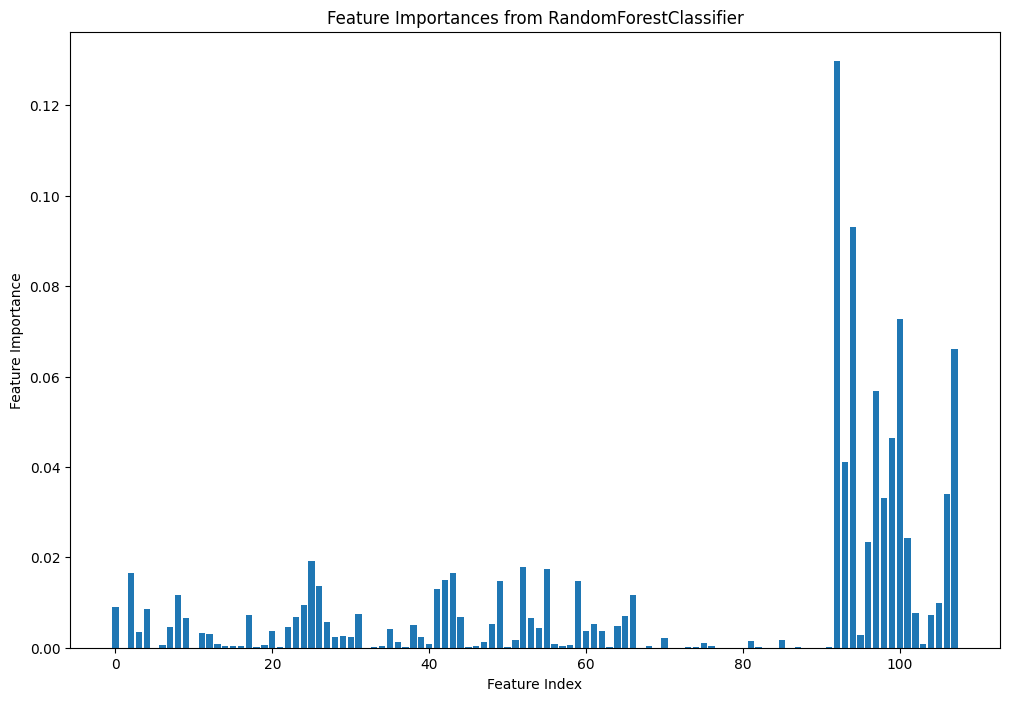

In [28]:
plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Feature Importance")
plt.title("Feature Importances from RandomForestClassifier")
plt.show()

We'll save the feature importances to a file so it can be used to filter our train and test sets in different configurations.

In [29]:
pkl.dump(
    feature_importances_df,
    open("../../../data/2021/processed/down_syndrome/feature_importances_df.pkl", "wb"),
)